# LibreFOMO — SJSU Headcount Training & Visualization

End-to-end notebook that:
1. Clones [bencejdanko/libreyolo](https://github.com/bencejdanko/libreyolo) and installs it
2. Downloads the **SJSU Headcount Scene-1** dataset from HuggingFace (`bdanko/sjsu-headcount-scene-1`)
3. Trains **LibreFOMO-s** (the lightweight MobileNetV2 point-localization model) for 10 epochs
4. Visualizes the predictions on validation images — predicted person locations as coloured circles overlaid on the original image

## 1 — Environment Setup

In [24]:
import os, subprocess, sys

if os.path.exists("libreyolo_repo"):
    import shutil
    shutil.rmtree("libreyolo_repo")

print("Cloning the 'librefomo' branch...")
subprocess.run(
    ["git", "clone", "-b", "librefomo", "https://github.com/bencejdanko/libreyolo", "libreyolo_repo"],
    check=True
)

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-e", "libreyolo_repo"],
    check=True
)

Cloning the 'librefomo' branch...


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', '-e', 'libreyolo_repo'], returncode=0)

In [25]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
  GPU: Tesla T4


## 2 — Download Dataset

`bdanko/sjsu-headcount-scene-1` is a YOLO-format dataset (standard `data.yaml` + `train/images/` + `valid/images/` layout).
It is cloned via `git` the same way all other LibreYOLO training datasets are fetched (marbles, RF5, etc.).

In [26]:
from pathlib import Path
import yaml
from huggingface_hub import snapshot_download

DATASET_ROOT = Path("sjsu-headcount-scene-1")
HF_REPO = "bdanko/sjsu-headcount-scene-1"

if not DATASET_ROOT.exists() or not (DATASET_ROOT / "data.yaml").exists():
    print(f"Downloading dataset {HF_REPO} via HF Hub...")
    snapshot_download(
        repo_id=HF_REPO,
        repo_type="dataset",
        local_dir=str(DATASET_ROOT),
        local_dir_use_symlinks=False
    )
    print("Dataset downloaded")
else:
    print("Dataset already present — skipping download")

# Patch data.yaml: replace relative path '.' with the absolute cloned directory
data_yaml_path = DATASET_ROOT / "data.yaml"
data_cfg = yaml.safe_load(data_yaml_path.read_text())
data_cfg["path"] = str(DATASET_ROOT.resolve())
data_yaml_path.write_text(yaml.dump(data_cfg, default_flow_style=False))

print(f"\nDataset config:")
print(f"  path : {data_cfg['path']}")
print(f"  train: {data_cfg['train']}")
print(f"  val  : {data_cfg.get('val', data_cfg.get('valid', 'N/A'))}")
print(f"  nc   : {data_cfg['nc']} ({data_cfg['names']})")

Dataset already present — skipping download

Dataset config:
  path : /content/sjsu-headcount-scene-1
  train: train/images
  val  : valid/images
  nc   : 1 (['person'])


In [4]:
# Quick sanity check — count images and labels
def count_split(split_dir):
    imgs = list(split_dir.rglob("*.jpg")) + list(split_dir.rglob("*.png"))
    # Try split_dir.parent / "labels" first (e.g., train/labels)
    lbl_dir = split_dir.parent / "labels"
    if not lbl_dir.exists():
        # Fallback to standard Roboflow layout (labels/train)
        lbl_dir = split_dir.parent.parent / "labels" / split_dir.name
    lbls = list(lbl_dir.rglob("*.txt")) if lbl_dir.exists() else []
    return len(imgs), len(lbls)

train_imgs, train_lbls = count_split(DATASET_ROOT / "train" / "images")
val_imgs, val_lbls     = count_split(DATASET_ROOT / "valid" / "images")
print(f"Train : {train_imgs} images, {train_lbls} label files")
print(f"Val   : {val_imgs} images, {val_lbls} label files")

Train : 406 images, 406 label files
Val   : 116 images, 116 label files


## 3 — Train LibreFOMO-s

LibreFOMO-s uses a **MobileNetV2 backbone (α=0.35)** with a single-pixel detection head.
Input resolution is **96×96** → output grid **12×12** (8× downsample).

Training uses:
- Adam, lr=3e-4, ReduceLROnPlateau on val F1
- Weighted CrossEntropy (background=1×, foreground=100×)
- No augmentation (plain resize + ImageNet normalisation)
- Val sweep over confidence thresholds every epoch

In [33]:
from libreyolo.models.librefomo.model import LibreFOMO

EPOCHS     = 10
BATCH      = 16
MODEL_SIZE = "m"   # "s" | "m" | "l"
PROJECT    = "runs/librefomo"
RUN_NAME   = f"sjsu_headcount_{MODEL_SIZE}"

model = LibreFOMO(model_path=None, size=MODEL_SIZE, nb_classes=1, device=device)
print(f"Model: LibreFOMO-{MODEL_SIZE}")
print(f"  Input size : {model.input_size}×{model.input_size}")
print(f"  Grid size  : {model.input_size//8}×{model.input_size//8}")
print(f"  Classes    : {model.nb_classes}")

Model: LibreFOMO-m
  Input size : 192×192
  Grid size  : 24×24
  Classes    : 1


In [34]:
import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)

results = model.train(
    allow_experimental=True,
    data=str(data_yaml_path),
    epochs=EPOCHS,
    batch=BATCH,
    lr0=3e-4,
    eval_interval=1,
    workers=2,
    device=device,
    project=PROJECT,
    name=RUN_NAME,
    exist_ok=True,
    patience=0,
)

save_dir = Path(results["save_dir"])
print(f"\nTraining complete. Saved to: {save_dir}")

01:00:36  Using device: cuda
01:00:36  Setting up training...
01:00:36  LibreFOMOLoss: nc=1, fg_weight=100.0
01:00:36  FOMO training dataset: 406 images
01:00:36  Grid size: 24×24 (imgsz=192, downsample=8)
01:00:36  Iterations per epoch: 26 (batch_per_rank=16, world_size=1)
01:00:36  Optimizer: adam
01:00:36    - pg0 (BN): 19 params
01:00:36    - pg1 (Conv, wd=0.0): 20 params
01:00:36    - pg2 (Bias): 20 params
01:00:36  Saving to: runs/librefomo/sjsu_headcount_m
01:00:36  Starting training for 10 epochs
01:00:36  Model: LibreFOMO-m
01:00:36  Batch size: 16
01:00:36  Learning rate: 0.0003
01:00:38  Epoch 1 - Average loss: 0.5141
01:00:38  Running FOMO validation for epoch 1
01:00:44  Epoch 1 val | loss=0.5571 | F1=0.0334 | P=0.0171 | R=0.6966 | MeanDist=1.085 | thresh=0.35 | nms_r=2 | TP=101 FP=5802 FN=44 | LR=0.000300
01:00:44  New best model saved - Epoch 1: metrics/F1=0.0334
01:00:44  Checkpoint saved: runs/librefomo/sjsu_headcount_m/weights/last.pt
01:00:46  Epoch 2 - Average loss:


Training complete. Saved to: runs/librefomo/sjsu_headcount_m


## 4 — Training Curves

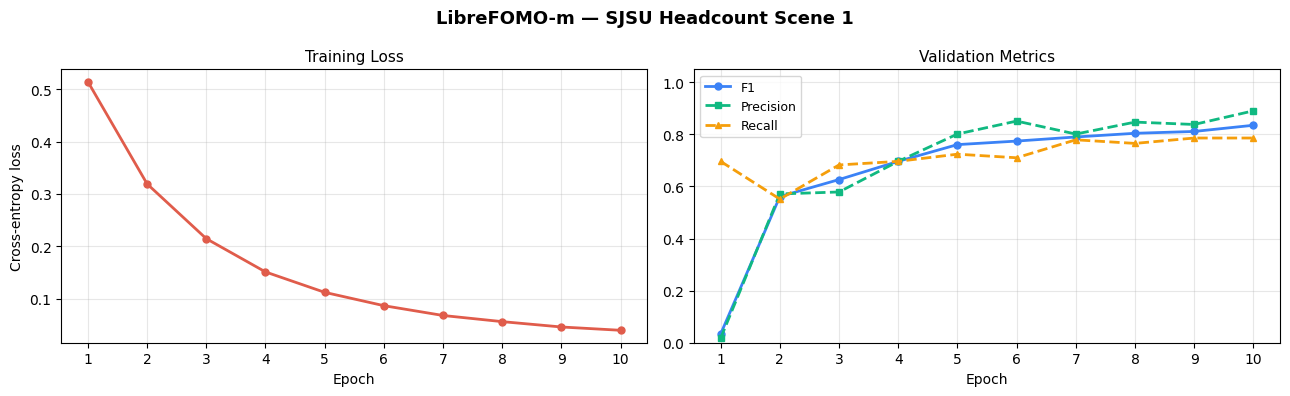


Final epoch metrics:
  F1        : 0.8352
  Precision : 0.8906
  Recall    : 0.7862
  MeanDist  : 0.264 grid cells


In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

epoch_losses = results.get("epoch_losses", [])
val_metrics  = [m for m in results.get("val_metrics", []) if m]

f1s    = [m.get("metrics/F1", 0)         for m in val_metrics]
precs  = [m.get("metrics/precision", 0)  for m in val_metrics]
recs   = [m.get("metrics/recall", 0)     for m in val_metrics]
epochs = range(1, len(epoch_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"LibreFOMO-{MODEL_SIZE} — SJSU Headcount Scene 1", fontsize=13, fontweight="bold")

# Loss
ax = axes[0]
ax.plot(epochs, epoch_losses, color="#e05c4b", linewidth=2, marker="o", markersize=5)
ax.set_title("Training Loss", fontsize=11)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.grid(True, alpha=0.3)

# F1 / Precision / Recall
ax = axes[1]
ep_val = range(1, len(f1s) + 1)
ax.plot(ep_val, f1s,   color="#3b82f6", linewidth=2, marker="o", markersize=5, label="F1")
ax.plot(ep_val, precs, color="#10b981", linewidth=2, marker="s", markersize=4, label="Precision", linestyle="--")
ax.plot(ep_val, recs,  color="#f59e0b", linewidth=2, marker="^", markersize=4, label="Recall",    linestyle="--")
ax.set_title("Validation Metrics", fontsize=11)
ax.set_xlabel("Epoch")
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(save_dir / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

if val_metrics:
    last = val_metrics[-1]
    print(f"\nFinal epoch metrics:")
    print(f"  F1        : {last.get('metrics/F1', 0):.4f}")
    print(f"  Precision : {last.get('metrics/precision', 0):.4f}")
    print(f"  Recall    : {last.get('metrics/recall', 0):.4f}")
    print(f"  MeanDist  : {last.get('metrics/mean_distance', 0):.3f} grid cells")

## 5 — Load Best Checkpoint

In [36]:
from libreyolo import LibreYOLO

weights_dir = save_dir / "weights"
best_pt  = weights_dir / "best.pt"
last_pt  = weights_dir / "last.pt"
ckpt_path = best_pt if best_pt.exists() else last_pt

trained = LibreYOLO(str(ckpt_path), device=device)
print(f"Loaded: {ckpt_path.name}")
print(f"  family : {trained.family}")
print(f"  size   : {trained.size}")
print(f"  imgsz  : {trained.input_size}")
print(f"  nc     : {trained.nb_classes}")

Loaded: best.pt
  family : librefomo
  size   : m
  imgsz  : 192
  nc     : 1


## 6 — Inference Visualisation

Found 116 validation images


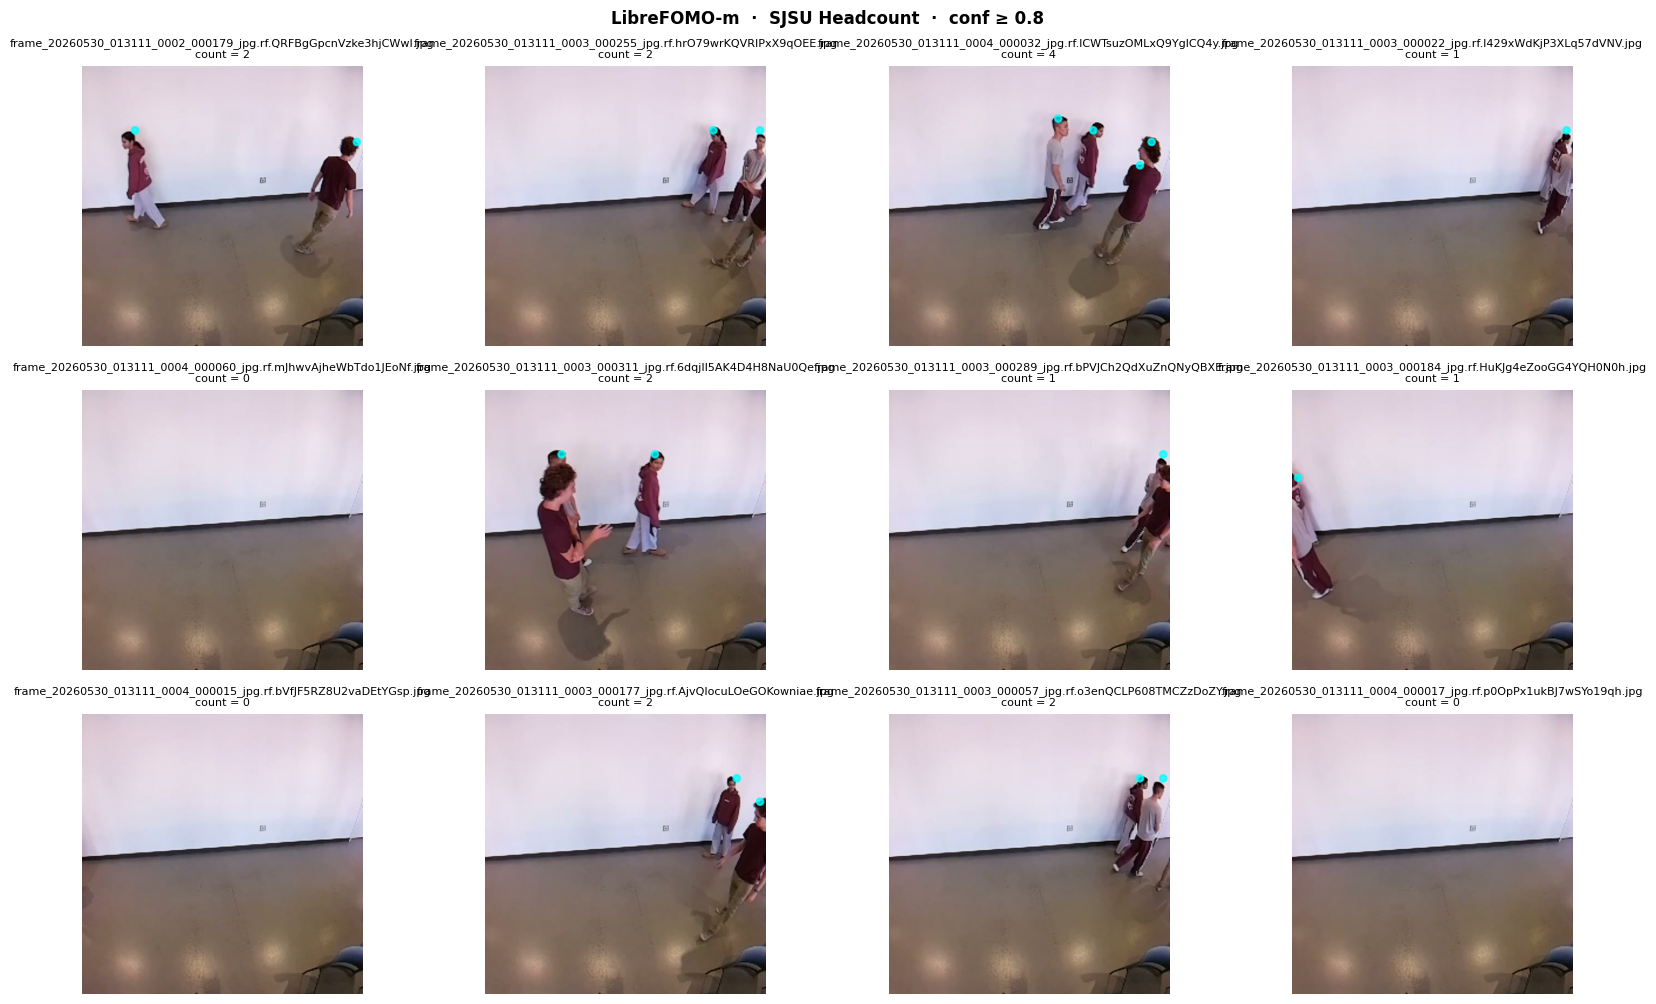

Saved → runs/librefomo/sjsu_headcount_m/val_predictions.png


In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import random, numpy as np
from pathlib import Path

val_dir   = DATASET_ROOT / "valid" / "images"
label_dir = DATASET_ROOT / "valid" / "labels"

val_images = sorted(val_dir.glob("*.jpg")) + sorted(val_dir.glob("*.png"))
print(f"Found {len(val_images)} validation images")


CONF_THRESHOLD = 0.80
N_SHOW  = min(12, len(val_images))
sample  = random.sample(val_images, N_SHOW)

N_COLS  = min(4, N_SHOW)
N_ROWS  = (N_SHOW + N_COLS - 1) // N_COLS
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 4.2, N_ROWS * 3.4))
fig.suptitle(
    f"LibreFOMO-{MODEL_SIZE}  ·  SJSU Headcount  ·  conf ≥ {CONF_THRESHOLD}",
    fontsize=12, fontweight="bold"
)

for ax, img_path in zip(np.array(axes).flat, sample):
    pil_img = Image.open(img_path).convert("RGB")
    result  = trained.predict(pil_img, conf=CONF_THRESHOLD, max_det=300)

    ax.imshow(pil_img)

    n_pred = 0
    if result.points is not None and len(result.points) > 0:
        # .xy is already in original image pixel coordinates
        xy    = result.points.xy.cpu().numpy()   # (N, 2)  x, y in pixels
        confs = result.points.conf.cpu().numpy() # (N,)
        for (px, py), c in zip(xy, confs):
            ax.add_patch(plt.Circle((px, py), radius=6,
                                    color="cyan", linewidth=1.5,
                                    fill=True, alpha=0.75))
            n_pred += 1

    ax.set_title(f"{img_path.name}\ncount = {n_pred}", fontsize=8)
    ax.axis("off")

for ax in np.array(axes).flat[N_SHOW:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(save_dir / "val_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {save_dir / 'val_predictions.png'}")


## 7 — Count Accuracy Summary

For each validation image, compare **predicted count** vs **ground-truth count** and compute mean absolute error (MAE).

In [38]:
from pathlib import Path

def load_gt_points(label_path, img_w, img_h):
    """Read YOLO-format label file → list of (px, py) in image pixels."""
    if not label_path.exists():
        return []
    pts = []
    for line in label_path.read_text().strip().splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cx, cy = float(parts[1]), float(parts[2])
        pts.append((cx * img_w, cy * img_h))
    return pts

all_images = sorted(val_dir.glob("*.jpg")) + sorted(val_dir.glob("*.png"))

pred_counts, gt_counts = [], []

trained.model.eval()          # ← was trained.nn.eval()
with torch.no_grad():
    for img_path in all_images:
        pil_img    = Image.open(img_path).convert("RGB")
        W, H       = pil_img.size
        label_path = label_dir / (img_path.stem + ".txt")
        gt_pts     = load_gt_points(label_path, W, H)
        result     = trained.predict(pil_img, conf=CONF_THRESHOLD, max_det=300)
        n_pred     = len(result.points) if result.points is not None else 0
        pred_counts.append(n_pred)
        gt_counts.append(len(gt_pts))

pred_counts = np.array(pred_counts)
gt_counts   = np.array(gt_counts)
mae  = np.mean(np.abs(pred_counts - gt_counts))
corr = np.corrcoef(pred_counts, gt_counts)[0, 1] if len(pred_counts) > 1 else float("nan")

print(f"Validation set ({len(all_images)} images)")
print(f"  MAE (count error) : {mae:.2f} persons")
print(f"  Pearson r          : {corr:.4f}")
print(f"  Mean GT count      : {gt_counts.mean():.1f}")
print(f"  Mean pred count    : {pred_counts.mean():.1f}")


Validation set (116 images)
  MAE (count error) : 0.34 persons
  Pearson r          : 0.8526
  Mean GT count      : 1.3
  Mean pred count    : 1.3


---
## Summary

| | |
|---|---|
| **Model** | `LibreFOMO-m` (MobileNetV2 α=0.5, 192×192) |
| **Dataset** | `bdanko/sjsu-headcount-scene-1` (YOLO format) |
| **Training** | Adam lr=3e-4, ReduceLROnPlateau on F1, 100× fg weight |
| **Inference** | `result.points.xy` → grid coords → image pixels |
| **Evaluation** | Threshold sweep over conf × NMS-radius → best F1 |

The checkpoint (`best.pt`) saved in `runs/librefomo/` is compatible with the LibreYOLO factory:
```python
from libreyolo import LibreYOLO
model = LibreYOLO("runs/librefomo/sjsu_headcount_s/weights/best.pt")
result = model.predict(image)
print(result.points.xy)   # person locations in grid coords
```